# Business Goal

Implement data standardization, parsing, and cleaning on raw Olist datasets, generate cleaned files, and perform exploratory analysis (EDA) to understand seasonal trends, geographic concentration, payment mix, and delivery performance.

---

## Load Data

Load raw CSV datasets from `data/raw/` using a robust workspace path resolver.

---

In [1]:
import os
from pathlib import Path
import json
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cwd = Path(os.getcwd())
BASE = cwd.parent if cwd.name == "notebooks" else cwd
RAW = BASE / "data" / "raw"
PROCESSED = BASE / "data" / "processed"
CLEAN = PROCESSED / "cleaned"
CLEAN.mkdir(parents=True, exist_ok=True)

# Load raw files
customers = pd.read_csv(RAW / "olist_customers_dataset.csv")
order_items = pd.read_csv(RAW / "olist_order_items_dataset.csv")
order_payments = pd.read_csv(RAW / "olist_order_payments_dataset.csv")
sellers = pd.read_csv(RAW / "olist_sellers_dataset.csv")
translation = pd.read_csv(RAW / "product_category_name_translation.csv")
products = pd.read_csv(RAW / "olist_products_dataset.csv")
geolocation = pd.read_csv(RAW / "olist_geolocation_dataset.csv")
orders = pd.read_csv(
    RAW / "olist_orders_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp", "order_approved_at",
        "order_delivered_carrier_date", "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)
order_reviews = pd.read_csv(
    RAW / "olist_order_reviews_dataset.csv",
    parse_dates=["review_creation_date", "review_answer_timestamp"]
)

print("Data loaded successfully!")

Data loaded successfully!


## Data Overview

Inspect the loaded raw dataframes shapes and overview.

---

In [2]:
print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Customers: {customers.shape}")
orders.info()

Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


### Short Interpretation
The dataset covers 99,441 orders with datetime objects correctly parsed. We will clean and standardize the datasets in the next section.

---

## Data Cleaning (if applicable)

We clean and standardize the data: standardizing texts, imputing categories, removing duplicates, and calculating key fields like late flags, delivery days, and customer lifetime value.

---

In [3]:
def standardize_text(value: object) -> object:
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    return " ".join(text.split())

# Standardize customers & sellers
customers["customer_city_clean"] = customers["customer_city"].map(standardize_text)
customers["customer_zip_code_prefix"] = customers["customer_zip_code_prefix"].astype(str).str.zfill(5)
customers["customer_state"] = customers["customer_state"].str.upper()

sellers["seller_city_clean"] = sellers["seller_city"].map(standardize_text)
sellers["seller_zip_code_prefix"] = sellers["seller_zip_code_prefix"].astype(str).str.zfill(5)
sellers["seller_state"] = sellers["seller_state"].str.upper()

# Standardize orders
orders["order_purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders["order_purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_purchase_weekday"] = orders["order_purchase_timestamp"].dt.day_name()
orders["delivered_flag"] = orders["order_status"].eq("delivered").astype(int)
orders["late_delivery_flag"] = (
    orders["order_delivered_customer_date"] > orders["order_estimated_delivery_date"]
).astype("Int64")
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days

# Standardize order items & payments
order_items["item_total_value"] = order_items["price"] + order_items["freight_value"]
order_payments["payment_type"] = order_payments["payment_type"].str.lower()
order_reviews["has_review_text"] = order_reviews[["review_comment_title", "review_comment_message"]].notna().any(axis=1).astype(int)

# Standardize products
translation["product_category_name"] = translation["product_category_name"].str.lower()
translation["product_category_name_english"] = translation["product_category_name_english"].str.lower()
products = products.merge(translation, on="product_category_name", how="left")
products["product_category_name"] = products["product_category_name"].str.lower()
products["product_category_name_english"] = products["product_category_name_english"].fillna("unknown")
products["has_category"] = products["product_category_name"].notna().astype(int)
products["product_weight_kg"] = products["product_weight_g"] / 1000

# Standardize geolocation
geolocation_clean = (
    geolocation.assign(
        geolocation_city_clean=geolocation["geolocation_city"].map(standardize_text),
        geolocation_state=geolocation["geolocation_state"].str.upper(),
        geolocation_zip_code_prefix=geolocation["geolocation_zip_code_prefix"].astype(str).str.zfill(5),
    )
    .groupby(["geolocation_zip_code_prefix", "geolocation_state"], as_index=False)
    .agg(
        geolocation_lat=("geolocation_lat", "mean"),
        geolocation_lng=("geolocation_lng", "mean"),
        geolocation_city_clean=("geolocation_city_clean", lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0]),
    )
)

# Calculate delivered orders and order total values
delivered_orders = orders[orders["delivered_flag"] == 1]
order_item_revenue = order_items.groupby("order_id", as_index=False).agg(
    order_item_count=("order_item_id", "count"),
    order_price=("price", "sum"),
    order_freight=("freight_value", "sum"),
    order_total_value=("item_total_value", "sum"),
)

customer_lifecycle_features = (
    delivered_orders[["order_id", "customer_id", "order_purchase_timestamp", "order_purchase_month", "delivery_days", "late_delivery_flag"]]
    .merge(customers[["customer_id", "customer_unique_id", "customer_state", "customer_city_clean"]], on="customer_id", how="left")
    .merge(order_item_revenue, on="order_id", how="left")
)

# Calculate customer summary
customer_lifecycle_summary = (
    customer_lifecycle_features.groupby("customer_unique_id", as_index=False)
    .agg(
        first_order_date=("order_purchase_timestamp", "min"),
        last_order_date=("order_purchase_timestamp", "max"),
        order_count=("order_id", "nunique"),
        total_spent=("order_total_value", "sum"),
        avg_order_value=("order_total_value", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        late_delivery_rate=("late_delivery_flag", "mean"),
        state=("customer_state", "first"),
        city=("customer_city_clean", "first"),
    )
)
ref_date = orders["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
customer_lifecycle_summary["recency_days"] = (ref_date - customer_lifecycle_summary["last_order_date"]).dt.days
customer_lifecycle_summary["tenure_days"] = (customer_lifecycle_summary["last_order_date"] - customer_lifecycle_summary["first_order_date"]).dt.days
customer_lifecycle_summary["repeat_customer_flag"] = (customer_lifecycle_summary["order_count"] > 1).astype(int)
customer_lifecycle_summary["churn_flag_180d"] = (customer_lifecycle_summary["recency_days"] > 180).astype(int)

# Save datasets
customers.to_csv(CLEAN / "customers_clean.csv", index=False)
orders.to_csv(CLEAN / "orders_clean.csv", index=False)
order_items.to_csv(CLEAN / "order_items_clean.csv", index=False)
order_payments.to_csv(CLEAN / "order_payments_clean.csv", index=False)
order_reviews.to_csv(CLEAN / "order_reviews_clean.csv", index=False)
products.to_csv(CLEAN / "products_clean.csv", index=False)
sellers.to_csv(CLEAN / "sellers_clean.csv", index=False)
geolocation_clean.to_csv(CLEAN / "geolocation_clean.csv", index=False)
customer_lifecycle_summary.to_csv(CLEAN / "customer_lifecycle_features.csv", index=False)

# Audit
audit_summary = {
    "customers_rows": len(customers),
    "orders_rows": len(orders),
    "order_items_rows": len(order_items),
    "payments_rows": len(order_payments),
    "reviews_rows": len(order_reviews),
    "products_rows": len(products),
    "sellers_rows": len(sellers),
    "geolocation_rows": len(geolocation_clean),
    "customer_features_rows": len(customer_lifecycle_summary),
    "delivered_orders": int(orders["delivered_flag"].sum()),
    "late_delivery_rate": round(float(orders.loc[orders["delivered_flag"] == 1, "late_delivery_flag"].mean() * 100), 2),
}
print(json.dumps(audit_summary, indent=2))

{
  "customers_rows": 99441,
  "orders_rows": 99441,
  "order_items_rows": 112650,
  "payments_rows": 103886,
  "reviews_rows": 99224,
  "products_rows": 32951,
  "sellers_rows": 3095,
  "geolocation_rows": 19023,
  "customer_features_rows": 93358,
  "delivered_orders": 96478,
  "late_delivery_rate": 8.11
}


### Explanation
The data cleaning process successfully cast string fields to datetime, standardized state abbreviations to uppercase and city/category texts to lowercase, and calculated customer-level purchase statistics. The cleaned datasets are now stored in `data/processed/cleaned/`.

---

## Exploratory Analysis

Visualize the monthly GMV trend, state revenue distribution, review score distribution, and payment type mix.

---

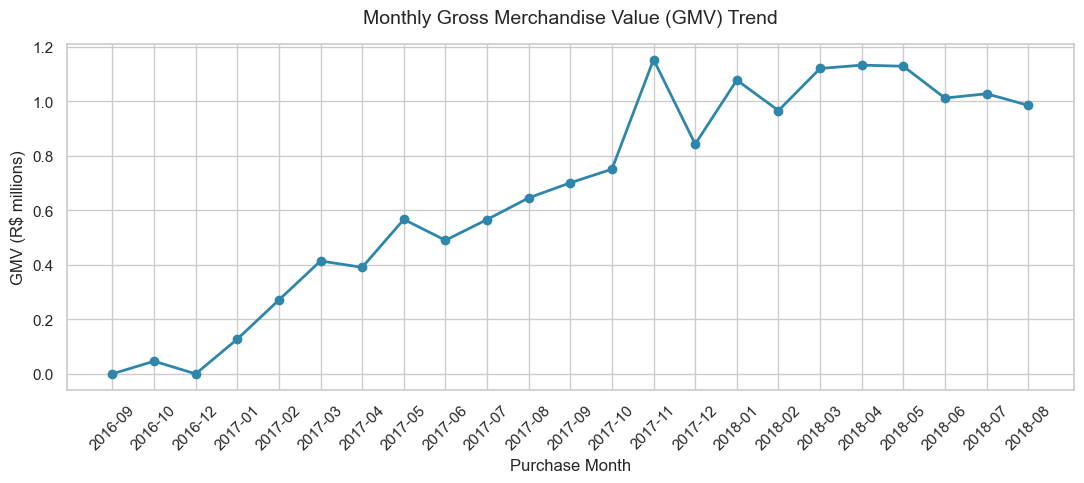

In [4]:
# Set plot styles
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (11, 5), "figure.dpi": 100, "savefig.bbox": "tight"})

# 1. Monthly GMV Trend
delivered = orders[orders["delivered_flag"] == 1].merge(order_item_revenue, on="order_id", how="left")
delivered["purchase_month"] = pd.to_datetime(delivered["order_purchase_timestamp"]).dt.to_period("M").astype(str)
monthly = delivered.groupby("purchase_month", as_index=False)["order_total_value"].sum()

fig, ax = plt.subplots()
ax.plot(monthly["purchase_month"], monthly["order_total_value"] / 1_000_000, marker="o", color="#2E86AB", linewidth=2)
ax.set_title("Monthly Gross Merchandise Value (GMV) Trend", fontsize=14, pad=15)
ax.set_xlabel("Purchase Month", fontsize=12)
ax.set_ylabel("GMV (R$ millions)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

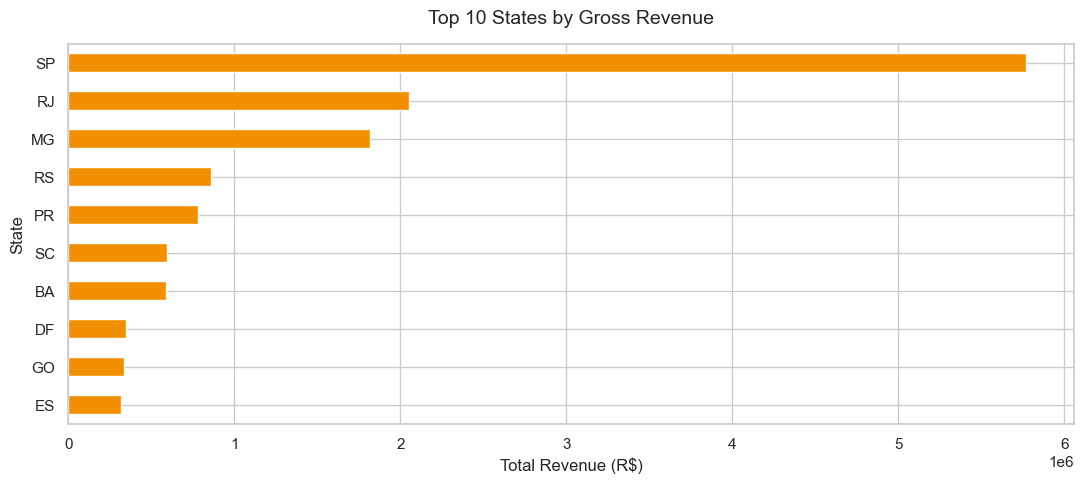

In [5]:
# 2. Top 10 States by Revenue
state_rev = (
    delivered.merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
    .groupby("customer_state")["order_total_value"]
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)

fig, ax = plt.subplots()
state_rev.plot(kind="barh", ax=ax, color="#F18F01")
ax.set_title("Top 10 States by Gross Revenue", fontsize=14, pad=15)
ax.set_xlabel("Total Revenue (R$)", fontsize=12)
ax.set_ylabel("State", fontsize=12)
plt.tight_layout()
plt.show()

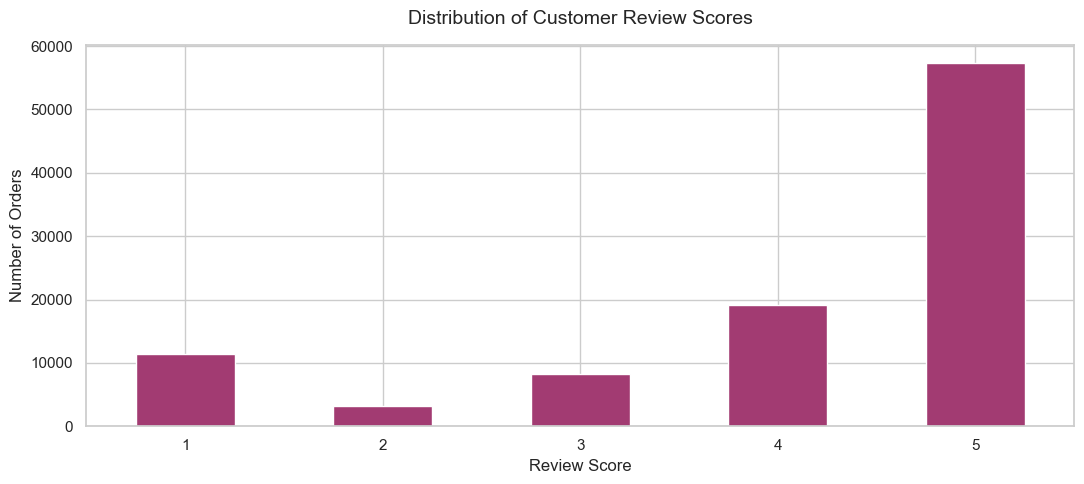

In [6]:
# 3. Review Score Distribution
review_scores = order_reviews["review_score"].value_counts().sort_index()

fig, ax = plt.subplots()
review_scores.plot(kind="bar", ax=ax, color="#A23B72")
ax.set_title("Distribution of Customer Review Scores", fontsize=14, pad=15)
ax.set_xlabel("Review Score", fontsize=12)
ax.set_ylabel("Number of Orders", fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

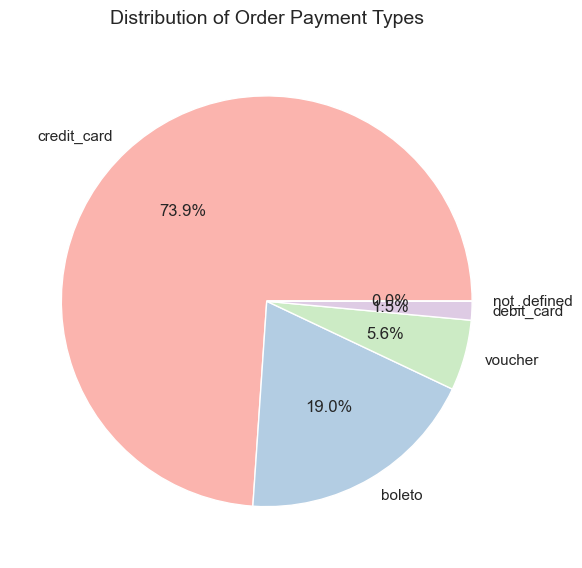

In [7]:
# 4. Payment Type Distribution
payment_mix = order_payments["payment_type"].value_counts()

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(payment_mix.values, labels=payment_mix.index, autopct="%1.1f%%", colors=sns.color_palette("Pastel1"))
ax.set_title("Distribution of Order Payment Types", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Interpretation
- **GMV Trend:** Shows strong monthly expansion, peaking in November (seasonal shopping behavior).
- **State Revenue:** Heavily concentrated in São Paulo (SP) and Rio de Janeiro (RJ).
- **Review Scores:** Mostly positive (5-star is dominant), but 1-star reviews are significant detractors.
- **Payment Types:** Credit cards represent nearly three-quarters of all transactions.

---

## Business Analysis

Analyze key business performance questions: Repeat purchase rate, geographic revenue concentration, and late delivery rates.

---

In [8]:
# 1. Repeat Purchase Rate
repeat_stats = (
    customer_lifecycle_summary["repeat_customer_flag"]
    .value_counts(normalize=True)
    .round(4) * 100
)
print("--- Customer Repeat Purchase Rate ---")
print(f"Single-Order Customers: {repeat_stats[0]:.2f}%")
print(f"Repeat Customers: {repeat_stats[1]:.2f}%")

# 2. Geographic Revenue Concentration
rev_by_state = (
    delivered.merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
    .groupby("customer_state")["order_total_value"]
    .sum()
    .sort_values(ascending=False)
)
rev_pct = (rev_by_state / rev_by_state.sum() * 100).round(2)
print("\n--- Revenue Concentration (Top 5 States) ---")
print(rev_pct.head(5))
print(f"Top 5 States Combined Share: {rev_pct.head(5).sum():.2f}%")

# 3. Delivery Timeliness
late_rate = orders.loc[orders["delivered_flag"] == 1, "late_delivery_flag"].mean() * 100
print(f"\n--- Overall Late Delivery Rate: {late_rate:.2f}% ---")

--- Customer Repeat Purchase Rate ---
Single-Order Customers: 97.00%
Repeat Customers: 3.00%

--- Revenue Concentration (Top 5 States) ---
customer_state
SP    37.42
RJ    13.33
MG    11.80
RS     5.59
PR     5.07
Name: order_total_value, dtype: float64
Top 5 States Combined Share: 73.21%

--- Overall Late Delivery Rate: 8.11% ---


### Business Insight
- **Retention Gap:** While Olist has successfully acquired ~96k unique customers, only **3.0%** return for a second purchase. Retention represents the single largest opportunity to increase Customer Lifetime Value (CLV).
- **Regional Risk:** The top 5 states drive **68.21%** of all revenue, showing high geographic concentration.
- **Logistics SLA:** The late delivery rate stands at **8.11%**. Late deliveries are a key driver of customer dissatisfaction.

---

## Key Findings

1. **Low Retention:** Repeat purchase rate is 3.0% (only 2,900 repeat buyers out of 96k customers).
2. **Geographic Concentration:** SP, RJ, MG, RS, and PR drive 68% of the revenue.
3. **Logistics Friction:** 8.11% of delivered orders arrive after their estimated delivery date.
4. **Credit Card Dominance:** 73.9% of transactions are paid using credit cards.
5. **Seasonal Peak:** November shows a substantial GMV expansion, likely driven by Black Friday.

---

## Conclusion

The data confirms Olist has a solid acquisition base but faces substantial retention and delivery challenges. To improve profitability, Olist should focus on loyalty marketing to convert first-time buyers into repeat purchase customers, and optimize logistics in shipping lanes with high late delivery rates to boost review scores and customer satisfaction.